In [61]:
from langgraph.graph import StateGraph,START,END
from langgraph.checkpoint.memory import InMemorySaver
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.messages import HumanMessage,AIMessage
from typing import TypedDict

In [62]:
class ChatState(TypedDict):
    result : str
    prompt : str
    history : list

In [63]:
graph = StateGraph(ChatState)

In [64]:
chatmodel = ChatGoogleGenerativeAI(model='gemini-3.5-flash-lite')

In [65]:
checkpointer = InMemorySaver()

In [66]:
def llmcall(state):
    history = state.get("history", [])   
    history.append(HumanMessage(state['prompt']))
    state['result'] = chatmodel.invoke(history).content[0]['text']
    history.append(AIMessage(state['result']))
    state['history'] = history
    return state

In [67]:
graph.add_node('llmcall',llmcall)
graph.add_edge(START,'llmcall')
graph.add_edge('llmcall',END)

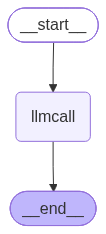

In [68]:
workflow = graph.compile(checkpointer=checkpointer)
workflow

In [75]:
while(True):
    userQuery = input("User :")
    if userQuery in ["exit","break","bye"]:
        break
    initial_state = {'prompt':userQuery}
    final_state = workflow.invoke(initial_state,config={
    "configurable": {
        "thread_id": "user-123"
    }
})
    print("AI: ",final_state['result'])

In [76]:
final_state['history']

[HumanMessage(content='Hey', additional_kwargs={}, response_metadata={}),
 AIMessage(content='Hey there! How can I help you today?', additional_kwargs={}, response_metadata={}, tool_calls=[], invalid_tool_calls=[]),
 HumanMessage(content='my name is kirnare', additional_kwargs={}, response_metadata={}),
 AIMessage(content="Nice to meet you, Kirnare! How's your day going?", additional_kwargs={}, response_metadata={}, tool_calls=[], invalid_tool_calls=[]),
 HumanMessage(content='what is 1 + 1', additional_kwargs={}, response_metadata={}),
 AIMessage(content="1 + 1 is 2! \n\nIs there anything else you'd like to calculate or talk about, Kirnare?", additional_kwargs={}, response_metadata={}, tool_calls=[], invalid_tool_calls=[]),
 HumanMessage(content='what is my name', additional_kwargs={}, response_metadata={}),
 AIMessage(content='Your name is Kirnare!', additional_kwargs={}, response_metadata={}, tool_calls=[], invalid_tool_calls=[])]